# K-Means Clustering — From Scratch + Scikit-learn (Beginner → Advanced)

This notebook is the **hands-on companion** to `kmeans_clustering_notes.md`.

We will:
1. Generate sample data with visible clusters
2. Implement K-Means **from scratch using only NumPy** (so you see every step of the algorithm)
3. Visualize each iteration (initialization → assignment → update → convergence)
4. Do the same thing in a few lines using **scikit-learn**
5. Implement the **Elbow Method** to choose K
6. Implement the **Silhouette Score**
7. Compare **Euclidean vs Manhattan distance**

> Beginner tip: run cells top to bottom, one at a time, and read the printed output/plots — that's where the intuition clicks.

## 1. Setup & Sample Data

We'll create synthetic 2D data with 3 natural blobs — just like the 'data points on a graph' example in the notes.

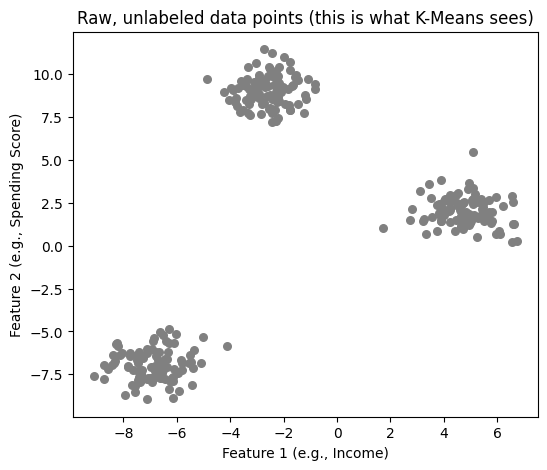

Shape of data: (300, 2)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Real-life framing: imagine these points are customers plotted by
# (Annual Income, Spending Score) - just simulated here for learning.
X, true_labels = make_blobs(n_samples=300, centers=3, cluster_std=0.9, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray')
plt.title("Raw, unlabeled data points (this is what K-Means sees)")
plt.xlabel("Feature 1 (e.g., Income)")
plt.ylabel("Feature 2 (e.g., Spending Score)")
plt.show()

print("Shape of data:", X.shape)

## 2. K-Means From Scratch

We implement the exact 3 steps from the notes:
1. **Initialize** K centroids randomly
2. **Assign** each point to nearest centroid (Euclidean distance)
3. **Update** centroids as the mean of assigned points
4. **Repeat** until centroids stop moving (convergence)

In [2]:
def euclidean_distance(a, b):
    """Straight-line distance between two points (or arrays of points)."""
    return np.sqrt(np.sum((a - b) ** 2, axis=-1))


def initialize_centroids(X, k, random_state=42):
    """Step 1: randomly pick k data points as the initial centroids."""
    rng = np.random.RandomState(random_state)
    indices = rng.choice(X.shape[0], size=k, replace=False)
    return X[indices]


def assign_clusters(X, centroids):
    """Step 2: assign every point to its nearest centroid."""
    distances = np.array([euclidean_distance(X, c) for c in centroids])  # shape (k, n_samples)
    return np.argmin(distances, axis=0)  # index of nearest centroid for each point


def update_centroids(X, labels, k):
    """Step 3: move each centroid to the mean of its assigned points."""
    new_centroids = np.zeros((k, X.shape[1]))
    for i in range(k):
        points_in_cluster = X[labels == i]
        if len(points_in_cluster) > 0:
            new_centroids[i] = points_in_cluster.mean(axis=0)
    return new_centroids


def kmeans_from_scratch(X, k, max_iters=100, tol=1e-4, random_state=42, verbose=True):
    centroids = initialize_centroids(X, k, random_state)
    history = [centroids.copy()]

    for iteration in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        movement = np.sum(euclidean_distance(new_centroids, centroids))
        if verbose:
            print(f"Iteration {iteration+1}: centroid movement = {movement:.5f}")

        centroids = new_centroids
        history.append(centroids.copy())

        if movement < tol:
            if verbose:
                print(f"Converged after {iteration+1} iterations (centroids stopped moving).")
            break

    labels = assign_clusters(X, centroids)
    return centroids, labels, history


k = 3
final_centroids, final_labels, history = kmeans_from_scratch(X, k)

Iteration 1: centroid movement = 7.22668
Iteration 2: centroid movement = 3.55676
Iteration 3: centroid movement = 0.00000
Converged after 3 iterations (centroids stopped moving).


### 2.1 Visualize the Final Clustering Result

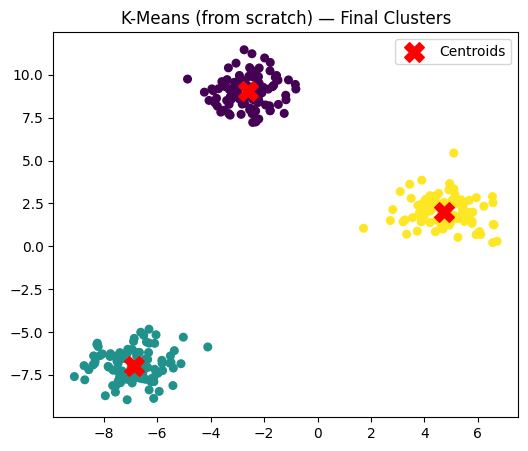

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap='viridis', s=30)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means (from scratch) — Final Clusters")
plt.legend()
plt.show()

### 2.2 Visualize How Centroids Move Over Iterations

This is the part that mirrors the whiteboard explanation in the notes: watch the centroids 'walk' towards the true center of each group.

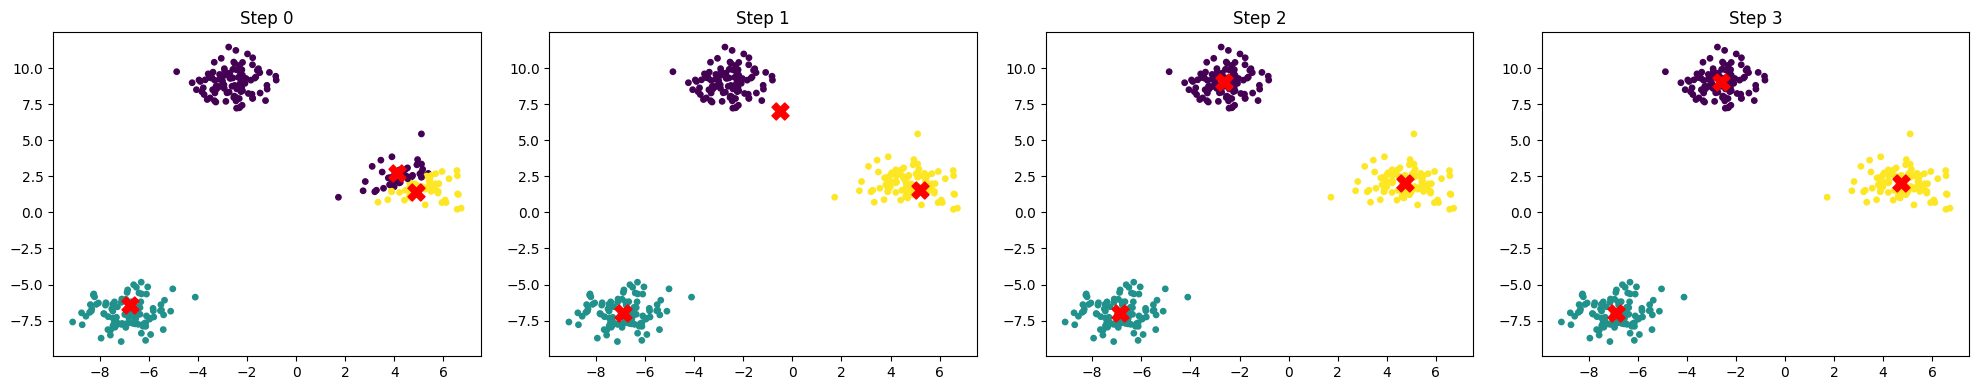

In [4]:
fig, axes = plt.subplots(1, len(history), figsize=(5 * len(history), 4))
if len(history) == 1:
    axes = [axes]

for i, centroids_snapshot in enumerate(history):
    labels_snapshot = assign_clusters(X, centroids_snapshot)
    axes[i].scatter(X[:, 0], X[:, 1], c=labels_snapshot, cmap='viridis', s=15)
    axes[i].scatter(centroids_snapshot[:, 0], centroids_snapshot[:, 1],
                     c='red', marker='X', s=150)
    axes[i].set_title(f"Step {i}")

plt.tight_layout()
plt.show()

## 3. The Same Thing with Scikit-learn (Production Way)

In real projects you won't write K-Means from scratch — you'll use `sklearn`, which also uses the smarter **K-Means++** initialization (mentioned in the notes) to avoid bad random starts.

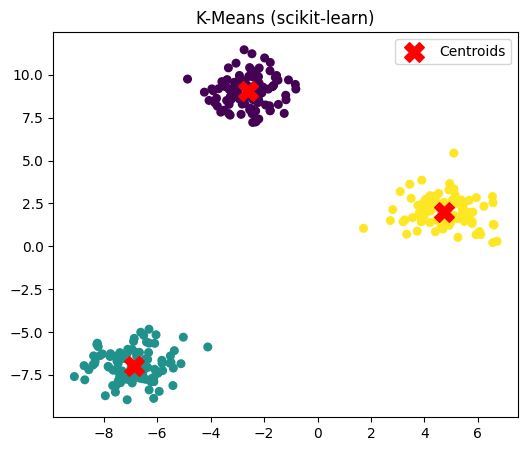

WCSS / Inertia: 459.1562364107747


In [5]:
from sklearn.cluster import KMeans

kmeans_sklearn = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
sklearn_labels = kmeans_sklearn.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=sklearn_labels, cmap='viridis', s=30)
plt.scatter(kmeans_sklearn.cluster_centers_[:, 0], kmeans_sklearn.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means (scikit-learn)")
plt.legend()
plt.show()

print("WCSS / Inertia:", kmeans_sklearn.inertia_)

## 4. Choosing K — The Elbow Method

Recall from the notes: we run K-Means for a range of K values, plot **WCSS (inertia)** vs K, and look for the 'elbow' — the point where adding more clusters stops giving much benefit.

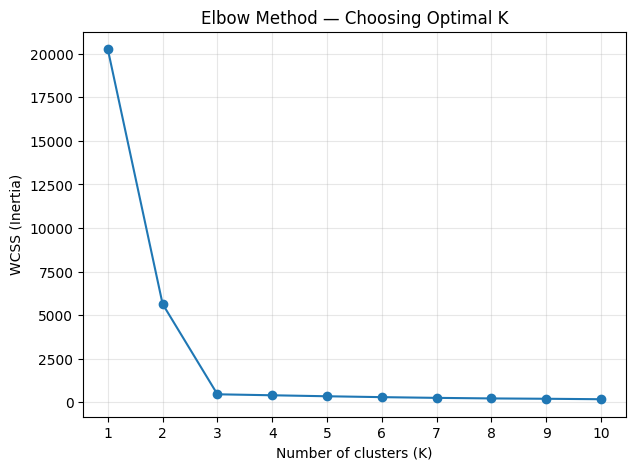

WCSS values: [20255.73, 5639.29, 459.16, 402.56, 345.97, 295.65, 254.01, 221.73, 202.38, 176.27]
Look for the 'elbow' bend in the plot above — here it should be around K=3,
which matches how we generated the data (3 real blobs).


In [6]:
wcss = []
k_range = range(1, 11)

for k_val in k_range:
    km = KMeans(n_clusters=k_val, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), wcss, marker='o')
plt.title("Elbow Method — Choosing Optimal K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.show()

print("WCSS values:", [round(w, 2) for w in wcss])
print("Look for the 'elbow' bend in the plot above — here it should be around K=3,")
print("which matches how we generated the data (3 real blobs).")

## 5. Silhouette Score (More Robust Way to Pick K)

The Silhouette Score measures how well-separated the clusters are (ranges from -1 to 1; higher = better defined clusters). Unlike the Elbow Method, you don't have to visually judge a 'bend'.

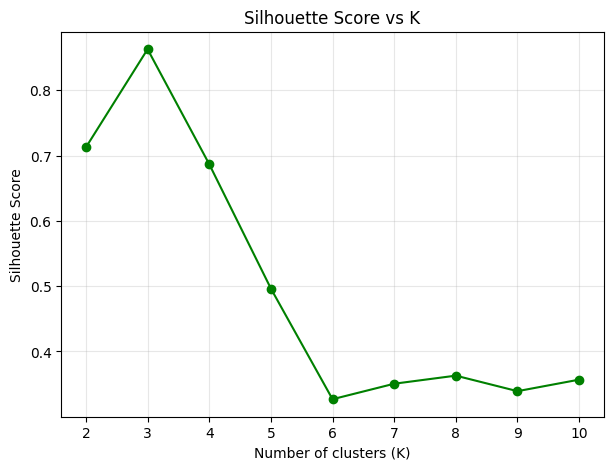

Best K according to Silhouette Score: 3


In [7]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = range(2, 11)  # silhouette score needs at least 2 clusters

for k_val in k_range_sil:
    km = KMeans(n_clusters=k_val, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range_sil), silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range_sil))
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(k_range_sil)[np.argmax(silhouette_scores)]
print(f"Best K according to Silhouette Score: {best_k}")

## 6. Euclidean vs Manhattan Distance — Side-by-Side

The notes explain Euclidean (straight-line / 'as the crow flies') vs Manhattan (grid-based / 'city block') distance. Let's implement both and see they can occasionally give different assignments.

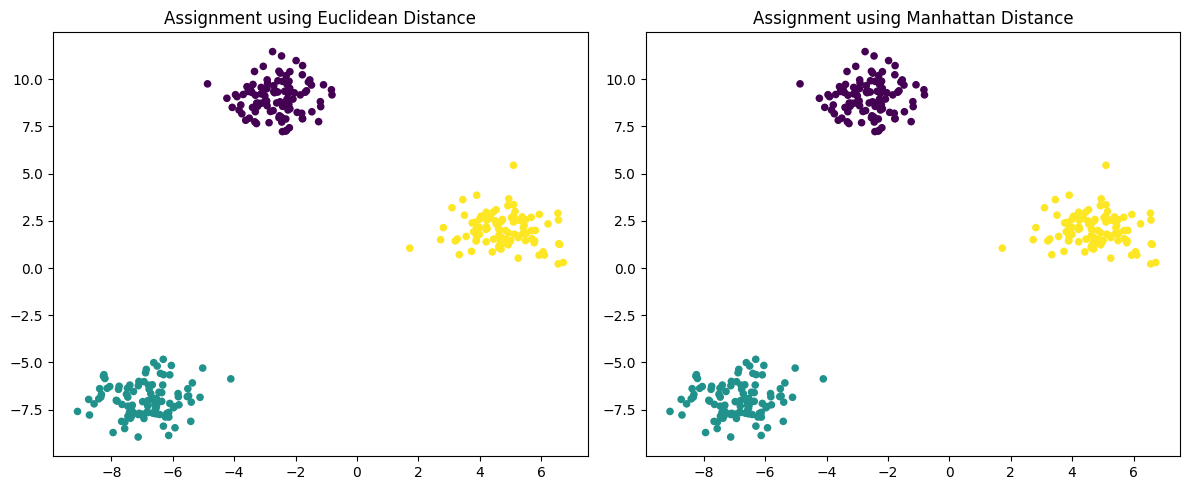

Points assigned differently between the two distance metrics: 0 / 300


In [8]:
def manhattan_distance(a, b):
    return np.sum(np.abs(a - b), axis=-1)


def assign_clusters_custom(X, centroids, distance_fn):
    distances = np.array([distance_fn(X, c) for c in centroids])
    return np.argmin(distances, axis=0)


# Compare final cluster assignment using Euclidean vs Manhattan distance
# (using the centroids we already found, just for illustration)
labels_euclidean = assign_clusters_custom(X, final_centroids, euclidean_distance)
labels_manhattan = assign_clusters_custom(X, final_centroids, manhattan_distance)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=labels_euclidean, cmap='viridis', s=20)
axes[0].set_title("Assignment using Euclidean Distance")
axes[1].scatter(X[:, 0], X[:, 1], c=labels_manhattan, cmap='viridis', s=20)
axes[1].set_title("Assignment using Manhattan Distance")
plt.tight_layout()
plt.show()

disagreement = np.sum(labels_euclidean != labels_manhattan)
print(f"Points assigned differently between the two distance metrics: {disagreement} / {len(X)}")

## 7. Why Feature Scaling Matters (Important Gotcha!)

From the notes: if one feature has a much bigger numeric range than another (e.g., Income in lakhs vs Age in years), it will dominate the distance calculation. Let's prove it.

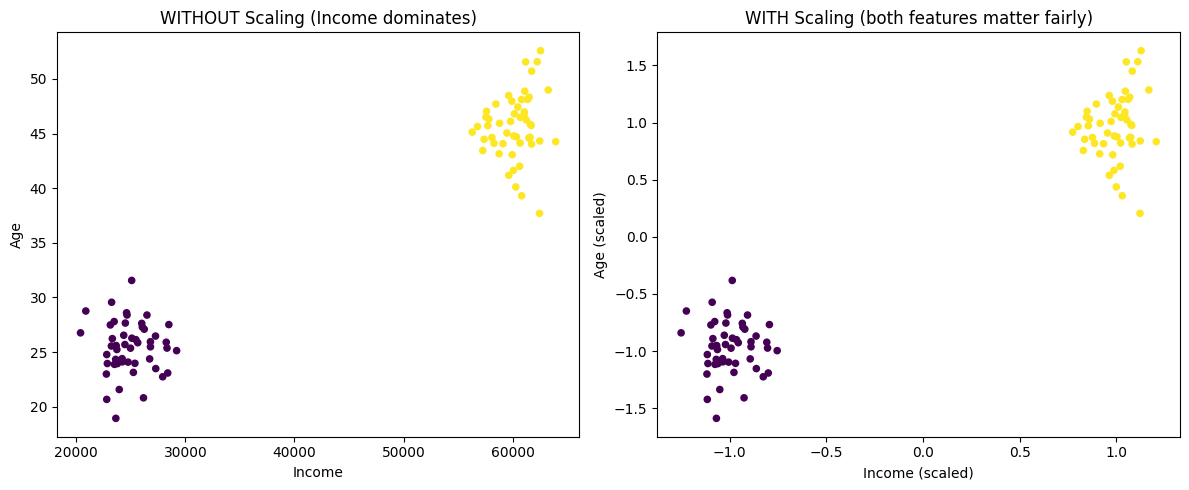

Lesson: ALWAYS scale features (e.g., StandardScaler) before running K-Means on real data.


In [9]:
# Simulate: Income (in thousands, big range) vs Age (small range, 18-60)
np.random.seed(1)
income = np.random.normal(loc=[30, 90, 150], scale=8, size=(300,)).reshape(-1) if False else None

# Build a small unscaled dataset with very different feature ranges
n_per_group = 50
group1 = np.column_stack([np.random.normal(25000, 2000, n_per_group), np.random.normal(25, 3, n_per_group)])
group2 = np.column_stack([np.random.normal(60000, 2000, n_per_group), np.random.normal(45, 3, n_per_group)])
X_unscaled = np.vstack([group1, group2])

from sklearn.preprocessing import StandardScaler

km_unscaled = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_unscaled)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)
km_scaled = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_unscaled[:, 0], X_unscaled[:, 1], c=km_unscaled.labels_, cmap='viridis', s=20)
axes[0].set_title("WITHOUT Scaling (Income dominates)")
axes[0].set_xlabel("Income"); axes[0].set_ylabel("Age")

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=km_scaled.labels_, cmap='viridis', s=20)
axes[1].set_title("WITH Scaling (both features matter fairly)")
axes[1].set_xlabel("Income (scaled)"); axes[1].set_ylabel("Age (scaled)")

plt.tight_layout()
plt.show()

print("Lesson: ALWAYS scale features (e.g., StandardScaler) before running K-Means on real data.")

## 8. Recap

- Implemented K-Means manually: **initialize → assign → update → repeat until convergence**
- Verified it matches scikit-learn's `KMeans`
- Used the **Elbow Method** and **Silhouette Score** to choose K
- Compared **Euclidean vs Manhattan** distance
- Saw why **feature scaling** is essential
